In [10]:
!pip install timm

In [11]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [12]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


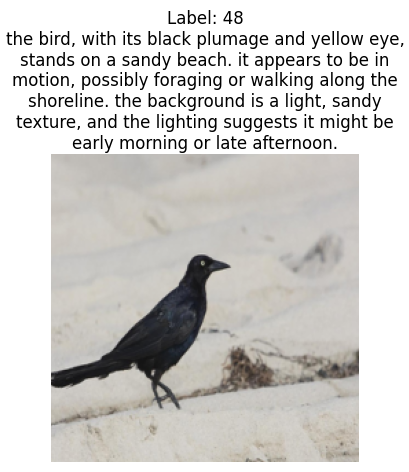

In [13]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [14]:
import torch
import torch.nn as nn
import timm

class BirdClassifierConvNeXtV2(nn.Module):
    # Sử dụng convnextv2_tiny hoặc convnextv2_base tùy thuộc vào tài nguyên GPU của bạn
    def __init__(self, num_classes=200, freeze_backbone=True, model_name='convnextv2_tiny'):
        super(BirdClassifierConvNeXtV2, self).__init__()
        
        # timm hỗ trợ sẵn tham số num_classes để tự động thay đổi lớp head (classifier) cuối cùng
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
        
        if freeze_backbone:
            for name, param in self.model.named_parameters():
                # Trong timm với ConvNeXt, lớp classifier cuối thường được đặt tên là 'head'
                if 'head' not in name:
                    param.requires_grad = False

    def forward(self, x):
        return self.model(x)

    def get_optimizer(self, base_lr=1e-5, head_lr=1e-3, weight_decay=1e-4):
        # Tách params để set learning rate khác nhau cho backbone và head
        head_params = []
        backbone_params = []
        
        for name, param in self.model.named_parameters():
            if not param.requires_grad:
                continue
            if 'head' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)
                
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': base_lr},
            {'params': head_params, 'lr': head_lr}
        ], weight_decay=weight_decay)
        
        return optimizer

    def predict_image(self, img_tensor, device):
        self.eval()
        with torch.no_grad():
            if len(img_tensor.shape) == 3:
                img_tensor = img_tensor.unsqueeze(0)
            
            img_tensor = img_tensor.to(device)
            outputs = self(img_tensor)
            
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_class = torch.max(probabilities, 1)
            
            return predicted_class.item(), confidence.item()

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo mô hình (đặt freeze_backbone=False nếu bạn muốn train toàn bộ mạng)
model = BirdClassifierConvNeXtV2(
    num_classes=200, 
    freeze_backbone=False, 
    model_name='convnextv2_tiny'
).to(device)

# Lấy optimizer (Learning rate cho Backbone nhỏ hơn Head để tránh phá vỡ pre-trained weights)
optimizer = model.get_optimizer(base_lr=1e-5, head_lr=1e-3)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

print(f"Đang sử dụng thiết bị: {device}")
print(f"Tổng số tham số cần huấn luyện: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Đang sử dụng thiết bị: cuda
Tổng số tham số cần huấn luyện: 28,020,296


In [16]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 50
patience = 3
epochs_no_improve = 0
best_test_acc = 0.0

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

print("BẮT ĐẦU HUẤN LUYỆN...")

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for inputs, labels, _ in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train

    # eval
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    test_pbar = tqdm(test_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Test ", leave=False)

    with torch.no_grad():
        for inputs, labels, _ in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * correct_test / total_test

    if scheduler is not None:
        scheduler.step()

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.2f}%")

    if epoch_test_acc > best_test_acc:
        print(f"Best acc: {epoch_test_acc:.2f}%. Đã lưu weights")
        best_test_acc = epoch_test_acc
        epochs_no_improve = 0
        # save
        torch.save(model.state_dict(), "best_convnext_cub.pth")
    else:
        epochs_no_improve += 1
        print(f"Test acc không tăng, early stopping: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"EARLY STOPPING. Đã dừng huấn luyện ở epoch {epoch+1}.")
            break

print("Hoàn thành quá trình huấn luyện!")

BẮT ĐẦU HUẤN LUYỆN...


Epoch [1/50] Train Loss: 1.6409, Acc: 61.86% | Test Loss: 0.6455, Acc: 81.45%
Best acc: 81.45%. Đã lưu weights


Epoch [2/50] Train Loss: 0.4112, Acc: 88.05% | Test Loss: 0.5474, Acc: 84.24%
Best acc: 84.24%. Đã lưu weights


Epoch [3/50] Train Loss: 0.2349, Acc: 92.96% | Test Loss: 0.5564, Acc: 84.81%
Best acc: 84.81%. Đã lưu weights


Epoch [4/50] Train Loss: 0.1365, Acc: 96.30% | Test Loss: 0.5314, Acc: 85.76%
Best acc: 85.76%. Đã lưu weights


...

Epoch [6/50] Train Loss: 0.0471, Acc: 99.03% | Test Loss: 0.5371, Acc: 86.93%
Best acc: 86.93%. Đã lưu weights


Epoch [7/50] Train Loss: 0.0296, Acc: 99.45% | Test Loss: 0.5417, Acc: 87.40%
Best acc: 87.40%. Đã lưu weights


Epoch [8/50] Train Loss: 0.0183, Acc: 99.78% | Test Loss: 0.5454, Acc: 87.23%
Test acc không tăng, early stopping: 1/3


Epoch [9/50] Train Loss: 0.0111, Acc: 99.87% | Test Loss: 0.5474, Acc: 87.35%
Test acc không tăng, early stopping: 2/3


Epoch [10/50] Train Loss: 0.0113, Acc: 99.87% | Test Loss: 0.5696, Acc: 86.81%
Test acc không tăng, early stopping: 3/3
EARLY STOPPING. Đã dừng huấn luyện ở epoch 10.
Hoàn thành quá trình huấn luyện!


In [17]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def evaluate_retrieval_from_classifier(model, dataloader, device, k_values=[1, 3, 5, 7, 10, 20]):
    model.eval()
    all_features = []
    all_labels = []
    
    print("1. Đang trích xuất đặc trưng (Bỏ qua lớp phân loại)...")
    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Extracting"):
            images = images.to(device)
            
            # --- BƯỚC QUAN TRỌNG NHẤT ---
            # Truy cập vào biến self.model (là mô hình timm) để lấy đặc trưng
            # forward_features(): chạy qua các lớp Conv của ConvNeXt
            features = model.model.forward_features(images)
            # forward_head(..., pre_logits=True): chạy qua lớp Pooling nhưng KHÔNG chạy qua lớp Linear phân loại cuối
            features = model.model.forward_head(features, pre_logits=True)
            
            # Chuẩn hóa L2 để tí nữa nhân ma trận sẽ tương đương Cosine Similarity
            features = F.normalize(features, p=2, dim=1)
            
            all_features.append(features.cpu())
            all_labels.append(labels)
            
    all_features = torch.cat(all_features, dim=0) # Kích thước [N, Embedding_Dim]
    all_labels = torch.cat(all_labels, dim=0)     # Kích thước [N]
    
    N = all_features.size(0)
    
    print("2. Đang tính ma trận khoảng cách (Cosine Similarity)...")
    # Nhân ma trận vector đặc trưng để lấy độ tương đồng
    similarity_matrix = torch.mm(all_features, all_features.t()) # [N, N]
    
    # Bỏ qua việc tự so sánh với chính nó (ảnh truy vấn = ảnh kết quả)
    similarity_matrix.fill_diagonal_(-float('inf'))
    
    max_k = max(k_values)
    # Lấy top K ảnh có similarity cao nhất
    _, top_k_indices = similarity_matrix.topk(max_k, dim=1)
    top_k_labels = all_labels[top_k_indices]
    
    print("3. Đang tính toán Metrics (Precision, Recall, mAP)...")
    results = {k: {'Precision': 0.0, 'Recall': 0.0, 'mAP': 0.0} for k in k_values}
    
    for i in range(N):
        query_label = all_labels[i].item()
        retrieved_labels = top_k_labels[i].numpy()
        
        # Số lượng ảnh cùng class (không tính chính nó)
        total_relevant = (all_labels == query_label).sum().item() - 1 
        if total_relevant == 0:
            continue
            
        relevance_array = (retrieved_labels == query_label)
        
        for k in k_values:
            rel_k = relevance_array[:k]
            hits = rel_k.sum()
            
            results[k]['Precision'] += hits / k
            results[k]['Recall'] += hits / total_relevant
            
            if hits > 0:
                precisions = [rel_k[:j+1].sum() / (j+1) for j in range(k) if rel_k[j]]
                # Average Precision cho query i
                results[k]['mAP'] += sum(precisions) / min(k, total_relevant)
                
    # Trung bình hóa cho toàn bộ N ảnh
    for k in k_values:
        results[k]['Precision'] /= N
        results[k]['Recall'] /= N
        results[k]['mAP'] /= N
        
    return results

# Giả sử 'model' của bạn là BirdClassifierConvNeXtV2 đã được train bằng CrossEntropy
k_vals = [1, 3, 5, 7, 10, 20]

# Đánh giá trên tập Test
metrics = evaluate_retrieval_from_classifier(model, test_loader, device, k_values=k_vals)

# In kết quả
print("\n" + "="*65)
print(f"{'K':<5} | {'Precision@K':<15} | {'Recall@K':<15} | {'mAP@K':<15}")
print("-" * 65)
for k in k_vals:
    p = metrics[k]['Precision']
    r = metrics[k]['Recall']
    m = metrics[k]['mAP']
    print(f"{k:<5} | {p:<15.4f} | {r:<15.4f} | {m:<15.4f}")
print("="*65)

1. Đang trích xuất đặc trưng (Bỏ qua lớp phân loại)...


Extracting: 100%|██████████| 182/182 [00:34<00:00,  5.27it/s]


2. Đang tính ma trận khoảng cách (Cosine Similarity)...
3. Đang tính toán Metrics (Precision, Recall, mAP)...

K     | Precision@K     | Recall@K        | mAP@K          
-----------------------------------------------------------------
1     | 0.8208          | 0.0294          | 0.8208         
3     | 0.8033          | 0.0861          | 0.7760         
5     | 0.7875          | 0.1405          | 0.7483         
7     | 0.7734          | 0.1931          | 0.7270         
10    | 0.7535          | 0.2686          | 0.6996         
20    | 0.6883          | 0.4887          | 0.6213         
